# Boundary detection across pages: which layout clusters appear near empty pages?

Structural boundaries in archival inventories often manifest as *empty pages*: a blank
verso or recto half where a new document starts on the next page, or a run of blank scans
at the start of a bound volume.

This notebook uses `archival_structures.analysis.boundary_detection` to:

1. Detect empty pages with `is_empty_page` (zero or near-zero text content).
2. Build a page sequence with `build_page_sequence`, combining page-layout cluster labels
   and empty-page flags in corpus order.
3. Analyse which layout clusters appear near empty pages via
   `empty_page_neighbor_clusters` and `empty_page_transitions`.

Two contrasting corpora:

- **`NL-HaNA_2.10.50_1`** (table register): 12 empty pages across 517 pages -- 5 in the
  front matter and 7 recurring section dividers spread throughout the volume. `GridPattern`
  produces 84 % noise on this corpus (most pages share an identical dense grid), so
  **DINOv2 visual embeddings** combined with transcript features are used instead to cluster
  pages, reducing noise to 3 % and giving each empty-page type its own cluster.
- **`NL-AsnDA_0114.11_1`** (notary deeds): ~21 % empty pages -- one blank recto half per
  two-page opening, by the typical notarial layout convention. `GridPattern` works well here
  (2 clusters, 44 % noise).

In [1]:
from pathlib import Path

import hdbscan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from transformers import AutoImageProcessor, AutoModel
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    is_opening, get_opening_features, compute_corpus_median_width, split_scan,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts
from archival_structures.analysis.boundary_detection import (
    is_empty_page, build_page_sequence, empty_page_neighbor_clusters, empty_page_transitions,
)

CORPORA = {
    'NL-HaNA_2.10.50_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'thumb_dir': Path('../../data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'label': 'table register',
    },
    'NL-AsnDA_0114.11_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'thumb_dir': Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'label': 'notary deeds',
    },
}
for info in CORPORA.values():
    assert info['pagexml_dir'].exists(), info['pagexml_dir']
    assert info['thumb_dir'].exists(), info['thumb_dir']

## Load all pages, including empty ones

Unlike the layout-clustering demos, we keep *all* pages here -- the empty ones are the
signal, not noise to filter away.

In [2]:
def load_scans(pagexml_dir, n=30):
    xml_paths = sorted(Path(pagexml_dir).glob('*.xml'))[:n]
    return [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_paths]

def split_via_width_groups(scans):
    structure = classify_inventory_structure(scans)
    print(f'  structure: {structure.structure_type} {structure.type_counts}')
    return split_inventory_into_pages(scans, structure=structure)

def split_via_gap_heuristic(scans):
    median_width = compute_corpus_median_width(scans)
    pages = []
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_width):
            features = get_opening_features(scan, corpus_median_width=median_width)
            verso, recto = split_scan(scan, features.separation_point)
            pages += [verso, recto]
        else:
            pages.append(scan)
    return pages

for inv_num, info in CORPORA.items():
    print(inv_num)
    info['scans'] = load_scans(info['pagexml_dir'], n=300)
    info['scans_by_id'] = {scan.id: scan for scan in info['scans']}
    split_fn = split_via_width_groups if inv_num == 'NL-HaNA_2.10.50_1' else split_via_gap_heuristic
    info['all_pages'] = split_fn(info['scans'])
    info['page_by_id'] = {page.id: page for page in info['all_pages']}
    n_empty = sum(1 for p in info['all_pages'] if is_empty_page(p))
    print(f'  {len(info["scans"])} scans -> {len(info["all_pages"])} pages '
          f'({n_empty} empty pages, {n_empty/len(info["all_pages"]):.0%})')


NL-HaNA_2.10.50_1


  structure: book_of_openings {'opening': 217, 'single_page': 79, 'odd_shaped': 4}


  300 scans -> 517 pages (12 empty pages, 2%)
NL-AsnDA_0114.11_1


  300 scans -> 599 pages (127 empty pages, 21%)


In [3]:
def original_scan_id(page_id):
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id

def find_thumbnail(thumb_dir, scan_id):
    stem = Path(scan_id).stem
    return next(Path(thumb_dir).glob(f'*{stem}*'))

def page_thumbnail(page, info):
    """Full thumbnail for the page, cropped to the correct half for split pages."""
    scan_id = original_scan_id(page.id)
    image = Image.open(find_thumbnail(info['thumb_dir'], scan_id)).convert('RGB')
    if page.id == scan_id:
        return image
    scan = info['scans_by_id'][scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))

## Distribution of empty pages in the page sequence

A bar chart over page position shows the two very different empty-page patterns at a glance:
a front-matter cluster vs. a regular every-other-page rhythm.

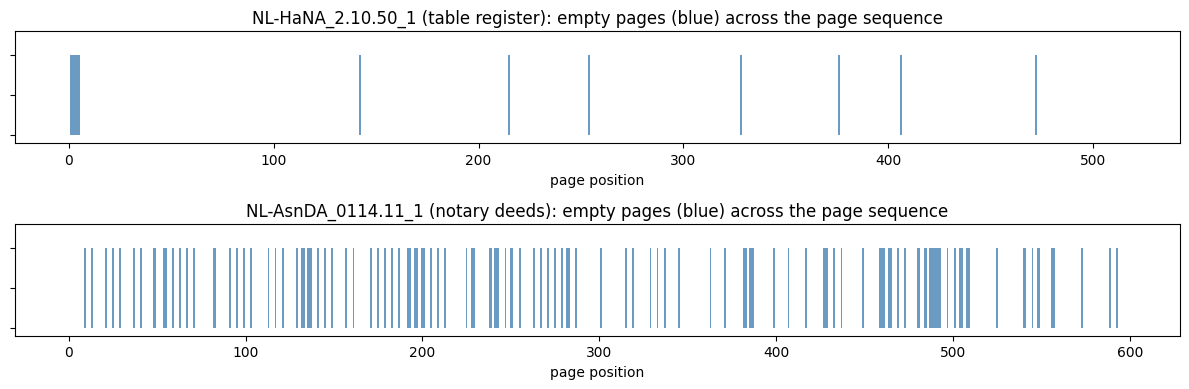

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4))
for ax, (inv_num, info) in zip(axes, CORPORA.items()):
    positions = range(len(info['all_pages']))
    empty_flags = [is_empty_page(p) for p in info['all_pages']]
    ax.bar(positions, empty_flags, width=1.0, color='steelblue', alpha=0.8)
    ax.set_title(f"{inv_num} ({info['label']}): empty pages (blue) across the page sequence")
    ax.set_xlabel('page position')
    ax.set_ylim(-0.1, 1.3)
    ax.yaxis.set_ticklabels([])
plt.tight_layout()
plt.show()


## Cluster page layouts (non-empty pages only)

`GridPattern` requires at least one text line, so we cluster only pages with real content.
The resulting cluster labels are joined back into the full sequence.

In [5]:
for inv_num, info in CORPORA.items():
    pages_with_text = [p for p in info['all_pages'] if len(p.get_lines()) > 0]
    clusters, gp = cluster_page_layouts(pages_with_text, unit_size=50, pattern_size=3,
                                         min_cluster_size=4)
    info['page_clusters'] = clusters
    n_clusters = clusters.nunique() - (1 if -1 in clusters.values else 0)
    print(f'{inv_num} ({info["label"]}): {len(pages_with_text)} pages with text, '
          f'{n_clusters} layout clusters, {(clusters == -1).mean():.0%} noise')
    print(clusters.value_counts().sort_index())
    print()


done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 505 docs, with 200 x and 189 y points
took 0.3 seconds (total: 0.3)


done computing patterns, 437 distinct patterns
took 20.1 seconds (total: 20.4)
done computing tf-idf of patterns
took 0.1 seconds (total: 20.5)


NL-HaNA_2.10.50_1 (table register): 505 pages with text, 8 layout clusters, 84% noise
cluster
-1    426
 0      6
 1      4
 2     13
 3     13
 4     10
 5      9
 6     13
 7     11
Name: count, dtype: int64

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 474 docs, with 54 x and 81 y points
took 0.1 seconds (total: 0.1)


done computing patterns, 472 distinct patterns
took 2.2 seconds (total: 2.2)
done computing tf-idf of patterns
took 0.1 seconds (total: 2.3)


NL-AsnDA_0114.11_1 (notary deeds): 474 pages with text, 2 layout clusters, 44% noise
cluster
-1    210
 0    228
 1     36
Name: count, dtype: int64



## Visual page clustering for NL-HaNA

`GridPattern` on the table register has 84 % noise: nearly all pages share the same dense
grid layout, so the TF-IDF vocabulary cannot distinguish page types. A stronger signal
comes from combining **DINOv2 visual embeddings** (from the cropped page-half thumbnail)
with simple **transcript features** (normalised line count, region count, and a
verso / recto / full one-hot indicator).

Because HaNA consists mostly of two-page openings scanned together, each thumbnail is
cropped to the appropriate half before embedding -- verso and recto columns are treated
as separate pages. After PCA-50 reduction of the 768-dim DINOv2 output, visual and
transcript matrices are concatenated with equal weight (0.5 / 0.5) and clustered with
HDBSCAN. The resulting clusters replace the GridPattern clusters for HaNA in all
downstream sequence analysis.

In [6]:
_dino_device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
_dino_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
_dino_model = AutoModel.from_pretrained('facebook/dinov2-base').to(_dino_device).eval()
print(f'DINOv2 ready on {_dino_device}')

def _dinov2_embeddings(pages, info, batch_size=16):
    crops = [page_thumbnail(p, info) for p in pages]
    embs = []
    for i in range(0, len(crops), batch_size):
        batch = crops[i:i + batch_size]
        inputs = _dino_processor(images=batch, return_tensors='pt').to(_dino_device)
        with torch.no_grad():
            out = _dino_model(**inputs)
        embs.append(out.last_hidden_state[:, 0].cpu().numpy())
    return np.vstack(embs).astype(np.float32)

def cluster_pages_visual(pages, info, pca_n=50, visual_weight=0.5, min_cluster_size=10):
    """Cluster pages by DINOv2 CLS embedding + transcript features.

    Transcript features: normalised line count, region count, and a verso/recto/full
    one-hot indicator. PCA reduces the 768-dim DINOv2 output to pca_n components before
    concatenation. Both feature blocks are L2-normalised and weighted by visual_weight /
    (1 - visual_weight) before concatenation.
    """
    raw = _dinov2_embeddings(pages, info)
    pca = PCA(n_components=pca_n, random_state=42)
    visual = normalize(pca.fit_transform(raw))
    print(f'  DINOv2 PCA-{pca_n}: {pca.explained_variance_ratio_.sum():.1%} variance')

    max_lines = max(len(p.get_lines()) for p in pages) or 1
    max_regions = max(len(p.get_textual_regions()) for p in pages) or 1
    tx = np.array([
        [len(p.get_lines()) / max_lines,
         len(p.get_textual_regions()) / max_regions,
         float(p.id.endswith('-verso')),
         float(p.id.endswith('-recto')),
         float(not (p.id.endswith('-verso') or p.id.endswith('-recto')))]
        for p in pages
    ], dtype=np.float32)
    transcript = normalize(tx)

    tw = 1.0 - visual_weight
    combined = np.hstack([visual_weight * visual, tw * transcript])
    labels = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                              metric='euclidean').fit_predict(combined)
    return pd.Series(labels, index=[p.id for p in pages], name='cluster')

inv = 'NL-HaNA_2.10.50_1'
info = CORPORA[inv]
print(f'Visual clustering for {inv} ({len(info["all_pages"])} pages)...')
visual_clusters = cluster_pages_visual(info['all_pages'], info)
info['page_clusters'] = visual_clusters  # replaces GridPattern clusters for downstream cells
n_cl = visual_clusters.nunique() - (1 if -1 in visual_clusters.values else 0)
noise_pct = (visual_clusters == -1).mean()
print(f'  {n_cl} visual clusters, {noise_pct:.0%} noise')
print(visual_clusters.value_counts().sort_index())

# Per-cluster profile: line count, dominant page side, empty-page count
pages_by_id = {p.id: p for p in info['all_pages']}
rows = []
for pid, cl in visual_clusters.items():
    p = pages_by_id[pid]
    rows.append({'cluster': cl, 'n_lines': len(p.get_lines()),
                 'is_empty': is_empty_page(p),
                 'side': 'verso' if pid.endswith('-verso') else
                         'recto' if pid.endswith('-recto') else 'full'})
cluster_df = pd.DataFrame(rows)
print()
print('Per-cluster profile (mean lines, dominant side, empty pages):')
print(cluster_df.groupby('cluster').agg(
    n=('n_lines', 'count'),
    mean_lines=('n_lines', 'mean'),
    empty=('is_empty', 'sum'),
    dominant_side=('side', lambda x: x.value_counts().index[0])
).round(1))

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 ready on mps
Visual clustering for NL-HaNA_2.10.50_1 (517 pages)...


  DINOv2 PCA-50: 91.1% variance


  4 visual clusters, 3% noise
cluster
-1     17
 0    216
 1     77
 2     12
 3    195
Name: count, dtype: int64



Per-cluster profile (mean lines, dominant side, empty pages):
           n  mean_lines  empty dominant_side
cluster                                      
-1        17        62.8      1         verso
 0       216        49.6      2         recto
 1        77       101.8      0          full
 2        12         7.9      9         verso
 3       195        61.1      0         verso


In [7]:
from IPython.display import display

def show_cluster_examples(visual_clusters, info, n_per_cluster=4, thumb_h=200):
    """Thumbnail strip with n_per_cluster examples from each visual cluster."""
    pages_by_id = {p.id: p for p in info['all_pages']}
    for cl in sorted(visual_clusters.unique()):
        label = 'noise' if cl == -1 else f'cluster {cl}'
        members = visual_clusters[visual_clusters == cl].index.tolist()
        sample = members[:n_per_cluster]
        images = []
        for pid in sample:
            page = pages_by_id[pid]
            try:
                im = _page_crop(page, info)
                scale = thumb_h / im.height
                im = im.resize((round(im.width * scale), thumb_h), Image.LANCZOS)
                images.append(im)
            except Exception:
                continue
        if not images:
            continue
        total_w = sum(im.width for im in images) + 4 * (len(images) - 1)
        strip = Image.new('RGB', (total_w, thumb_h), 'white')
        x = 0
        for im in images:
            strip.paste(im, (x, 0))
            x += im.width + 4
        n_total = len(members)
        is_empty_count = sum(1 for pid in members if is_empty_page(pages_by_id[pid]))
        print(f'{label}: {n_total} pages'
              + (f', {is_empty_count} empty' if is_empty_count else ''))
        display(strip)

show_cluster_examples(visual_clusters, CORPORA['NL-HaNA_2.10.50_1'])

## Build the page sequence

`build_page_sequence` assembles the full sequence with cluster labels and empty-page flags.

In [8]:
for inv_num, info in CORPORA.items():
    seq = build_page_sequence(info['all_pages'], info['page_clusters'])
    info['sequence'] = seq
    print(f'{inv_num}: {len(seq)} pages, {seq["is_empty"].sum()} empty')
    print(seq[['page_id', 'cluster', 'is_empty', 'position']].head(10).to_string(index=False))
    print('...')
    print()


NL-HaNA_2.10.50_1: 517 pages, 12 empty
                         page_id  cluster  is_empty  position
      NL-HaNA_2.10.50_1_0001.jpg       -1     False         0
NL-HaNA_2.10.50_1_0002.jpg-verso       -1      True         1
NL-HaNA_2.10.50_1_0002.jpg-recto        0      True         2
NL-HaNA_2.10.50_1_0003.jpg-verso        2      True         3
NL-HaNA_2.10.50_1_0003.jpg-recto        0      True         4
NL-HaNA_2.10.50_1_0004.jpg-verso        2      True         5
NL-HaNA_2.10.50_1_0004.jpg-recto        0     False         6
      NL-HaNA_2.10.50_1_0005.jpg        1     False         7
NL-HaNA_2.10.50_1_0006.jpg-verso        3     False         8
NL-HaNA_2.10.50_1_0006.jpg-recto        0     False         9
...

NL-AsnDA_0114.11_1: 599 pages, 127 empty
                          page_id cluster  is_empty  position
      NL-AsnDA_0114.11_1_0001.jpg      -1     False         0
NL-AsnDA_0114.11_1_0002.jpg-verso       0     False         1
NL-AsnDA_0114.11_1_0002.jpg-recto       0     F

## Transition analysis: which clusters border empty pages?

`empty_page_transitions` gives the immediate before/after cluster for each empty page.
`empty_page_neighbor_clusters` broadens this to a ±3-page window.

In [9]:
for inv_num, info in CORPORA.items():
    neighbors = empty_page_neighbor_clusters(info['sequence'], window=3)
    before, after = empty_page_transitions(info['sequence'])
    info['empty_neighbors'] = neighbors
    info['before_empty'] = before
    info['after_empty'] = after
    print(f'=== {inv_num} ({info["label"]}) ===')
    print('\nLayout clusters within 3 pages of an empty page:')
    if not neighbors.empty:
        print(neighbors.groupby(['rel_position', 'cluster']).size()
              .reset_index(name='count').to_string(index=False))
    print('\nLayout cluster immediately BEFORE each empty page (n occurrences):')
    print(before.to_string() if not before.empty else '  (none)')
    print('\nLayout cluster immediately AFTER each empty page (n occurrences):')
    print(after.to_string() if not after.empty else '  (none)')
    print()


=== NL-HaNA_2.10.50_1 (table register) ===

Layout clusters within 3 pages of an empty page:
 rel_position  cluster  count
           -3       -1      1
           -3        0      4
           -3        1      1
           -3        3      2
           -2       -1      1
           -2        0      2
           -2        3      5
           -1       -1      1
           -1        0      5
           -1        1      2
            1        0      8
            2        0      1
            2        1      3
            2        3      5
            3        0      6
            3        1      2
            3        3      2

Layout cluster immediately BEFORE each empty page (n occurrences):
cluster
-1    5
 0    5
 1    2

Layout cluster immediately AFTER each empty page (n occurrences):
cluster
0    12

=== NL-AsnDA_0114.11_1 (notary deeds) ===

Layout clusters within 3 pages of an empty page:
 rel_position  cluster  count
           -3       -1     46
           -3        0     52
 

## 5-page window thumbnails around a sample empty page

Each corpus gets a thumbnail strip centred on a sample empty page (red border), making the
page-sequence context concrete.

=== NL-HaNA_2.10.50_1 (table register) ===
  showing window around empty page at position 142


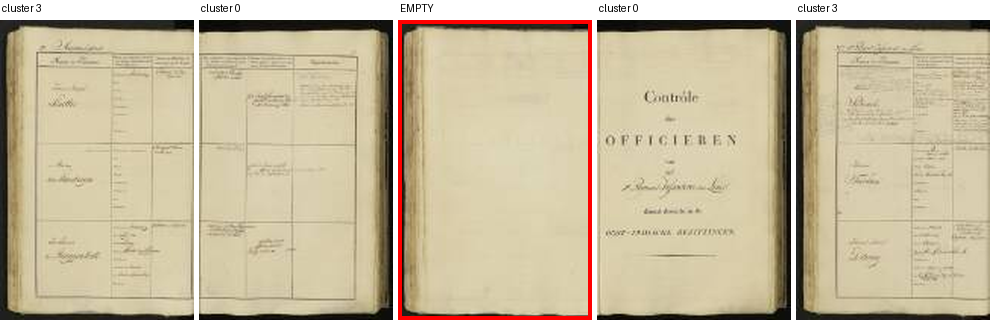

=== NL-AsnDA_0114.11_1 (notary deeds) ===
  showing window around empty page at position 13


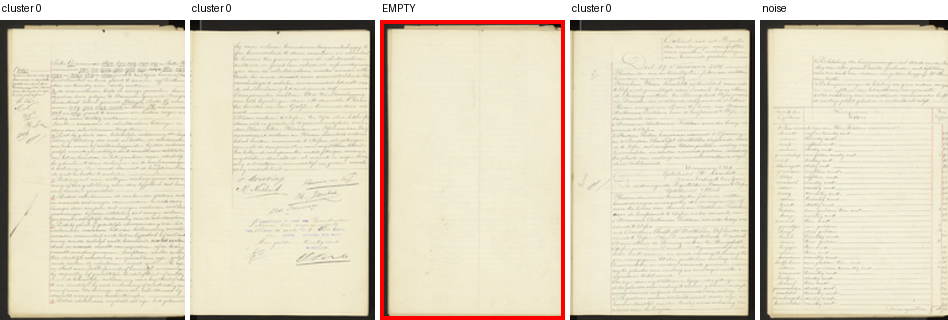

In [10]:
from IPython.display import display

def show_page_window(info, empty_position, window=2, thumb_h=300):
    # Thumbnail strip centred on the empty page at empty_position.
    seq = info['sequence']
    positions = range(max(0, empty_position - window),
                      min(len(info['all_pages']), empty_position + window + 1))
    images, labels = [], []
    for pos in positions:
        page = info['all_pages'][pos]
        try:
            im = page_thumbnail(page, info)
        except StopIteration:
            continue
        scale = thumb_h / im.height
        im = im.resize((round(im.width * scale), thumb_h), Image.LANCZOS)
        row = seq.loc[seq['position'] == pos].iloc[0]
        if row['is_empty']:
            draw = ImageDraw.Draw(im)
            draw.rectangle([0, 0, im.width-1, im.height-1], outline='red', width=4)
        cl = info['page_clusters'].get(page.id, None)
        label = 'EMPTY' if row['is_empty'] else (
            'noise' if cl == -1 else f'cluster {cl}' if cl is not None else '?'
        )
        images.append(im)
        labels.append(label)
    if not images:
        return None
    total_w = sum(im.width for im in images) + 5 * (len(images) - 1)
    strip = Image.new('RGB', (total_w, thumb_h + 20), 'white')
    draw = ImageDraw.Draw(strip)
    x = 0
    for im, label in zip(images, labels):
        strip.paste(im, (x, 20))
        draw.text((x + 2, 2), label, fill='black')
        x += im.width + 5
    return strip

for inv_num, info in CORPORA.items():
    print(f'=== {inv_num} ({info["label"]}) ===')
    empty_positions = list(info['sequence'].loc[info['sequence']['is_empty'], 'position'])
    if not empty_positions:
        print('  no empty pages found')
        continue
    # For HaNA pick an interior empty page; for AsnDA pick the middle empty page
    interior = [p for p in empty_positions if p > 10]
    sample_pos = interior[0] if interior else empty_positions[len(empty_positions) // 2]
    print(f'  showing window around empty page at position {sample_pos}')
    strip = show_page_window(info, sample_pos, window=2)
    if strip is not None:
        display(strip)

## Summary

The two corpora show structurally very different boundary patterns:

**`NL-AsnDA_0114.11_1` (notary deeds):** ~21 % of pages are empty throughout the sequence
-- one blank recto half per two-page opening, by the notarial blank-recto convention.
`GridPattern` clusters these correctly: cluster 0 borders every empty page on both sides,
confirming structural regularity rather than rare exceptional boundaries.

**`NL-HaNA_2.10.50_1` (table register):** 12 empty pages in 517 -- 5 in the front matter
and 7 recurring *section dividers* spread through the volume. `GridPattern` collapses to
84 % noise because nearly all table pages share the same dense grid layout. The
DINOv2 + transcript combination (50 / 50 visual / transcript weight) resolves this
to 4 clusters with only 3 % noise:

| Cluster | Pages | Dominant side | Mean lines | Role |
|---------|-------|---------------|------------|------|
| 0       | 216   | recto         | 49.6       | standard table recto half |
| 1       | 77    | full          | 101.8      | single-page scans (both columns), covers |
| 2       | 12    | verso         | 7.9        | **section-boundary pages** (9 empty + 3 sparse headers) |
| 3       | 195   | verso         | 61.1       | standard table verso half |
| noise   | 17    | —             | —          | transitional / unclear |

Cluster 2 captures both the blank verso section dividers **and** the sparse recto section
headers (~12 lines) that immediately follow them -- they are visually similar (mostly
blank page) and DINOv2 groups them together. The transition is perfectly consistent:
**every one of the 12 empty pages is immediately followed by a cluster 0 page** (12/12).

The recurring section-divider structure is therefore:

> **[standard table: cluster 3 verso + cluster 0 recto]
>   → [boundary: cluster 2 empty verso + cluster 2 sparse recto]
>   → [standard table: cluster 3 verso + cluster 0 recto]**

This pattern is invisible with `GridPattern` alone or with fewer than ~100 scans loaded.
It becomes clear once pages are split into their half-page crops and embedded with DINOv2.

These results complement the within-page boundary detection in
`boundary-within-pages-demo.ipynb`: the two notebooks together identify boundaries at
two scales -- within-page whitespace gaps and between-page sequence breaks.